# Import libraries

In [1]:
%load_ext autoreload
%autoreload 2

# Standard library
from pathlib import Path
import pprint

# Third-party libraries
import duckdb
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Custom osbad library for anomaly detection
import osbad.config as bconf
import osbad.hyperparam as hp
import osbad.modval as modval
import osbad.stats as bstats
import osbad.viz as bviz
from osbad.database import BenchDB
from osbad.scaler import CycleScaling
from osbad.model import ModelRunner

# Import dataset

## Define filepath

In [2]:
# Define a global variable to save fig output
# The definition of PIPELINE_OUTPUT_DIR can be
# found in config.py
PIPELINE_OUTPUT_DIR = bconf.PIPELINE_OUTPUT_DIR

In [3]:
# Load only the training dataset
db_filepath = str(
    Path.cwd()
    .parent
    .joinpath("database","train_dataset_severson.db"))

## Get the cell inventory of the training dataset

In [4]:
# Create a DuckDB connection
con = duckdb.connect(
    db_filepath,
    read_only=True)

# Load all training dataset from duckdb
df_duckdb = con.execute(
    "SELECT * FROM df_train_dataset_sv").fetchdf()

# Get the cell index of training dataset
unique_cell_index_train = df_duckdb["cell_index"].unique()
print(f"Unique cell index: {unique_cell_index_train}")

Unique cell index: ['2017-05-12_5_4C-50per_3C_CH13' '2017-05-12_5_4C-50per_3C_CH14'
 '2017-05-12_5_4C-60per_3C_CH15' '2017-05-12_5_4C-60per_3C_CH16'
 '2017-05-12_5_4C-70per_3C_CH17' '2017-05-12_5_4C-70per_3C_CH18'
 '2017-05-12_6C-40per_3C_CH25' '2017-05-12_6C-40per_3C_CH26'
 '2017-05-12_6C-50per_3C_CH27' '2017-05-12_6C-50per_3C_CH28'
 '2017-05-12_6C-60per_3C_CH29' '2017-05-12_6C-60per_3C_CH30'
 '2017-05-12_7C-40per_3C_CH37' '2017-05-12_7C-40per_3C_CH38'
 '2017-05-12_4C-80per_4C_CH5' '2017-05-12_4C-80per_4C_CH6'
 '2017-05-12_4_4C-80per_4_4C_CH7' '2017-05-12_5_4C-80per_5_4C_CH11'
 '2017-05-12_5_4C-80per_5_4C_CH12' '2017-05-12_3_6C-80per_3_6C_CH1'
 '2017-05-12_3_6C-80per_3_6C_CH2' '2017-05-12_3_6C-80per_3_6C_CH3'
 '2017-05-12_5_4C-40per_3_6C_CH19']


In [5]:
# Get the cell-ID from cell_inventory
selected_cell_label = "2017-05-12_5_4C-70per_3C_CH17"

# Create a subfolder to store fig output
# corresponding to each cell-index
selected_cell_artifacts_dir = bconf.artifacts_output_dir(
    selected_cell_label)

## Drop true labels

* Drop true outlier labels (denoted as ``outlier``) from the dataframe and select only relevant features for ML:
  * ``cell_index``: The cell-ID for data and model versioning purposes;
  * ``cycle_index``: The cycle number of each cell;
  * ``discharge_capacity``: Discharge capacity of the cell;
  * ``voltage``: Discharge voltage of the cell.

In [6]:
# Import the BenchDB class
# Load only the dataset based on the selected cell
benchdb = BenchDB(
    db_filepath,
    selected_cell_label)

# load the benchmarking dataset
df_selected_cell = benchdb.load_benchmark_dataset(
    dataset_type="train")

if df_selected_cell is not None:

    filter_col = [
        "cell_index",
        "cycle_index",
        "discharge_capacity",
        "voltage"]

    # Drop true labels from the benchmarking dataset
    # and filter for selected columns only
    df_selected_cell_without_labels = benchdb.drop_labels(
        df_selected_cell,
        filter_col)

Database is found in the given filepath.
Loading benchmarking dataset now...
****************************************************************************************************


## Plot cycling data without labels

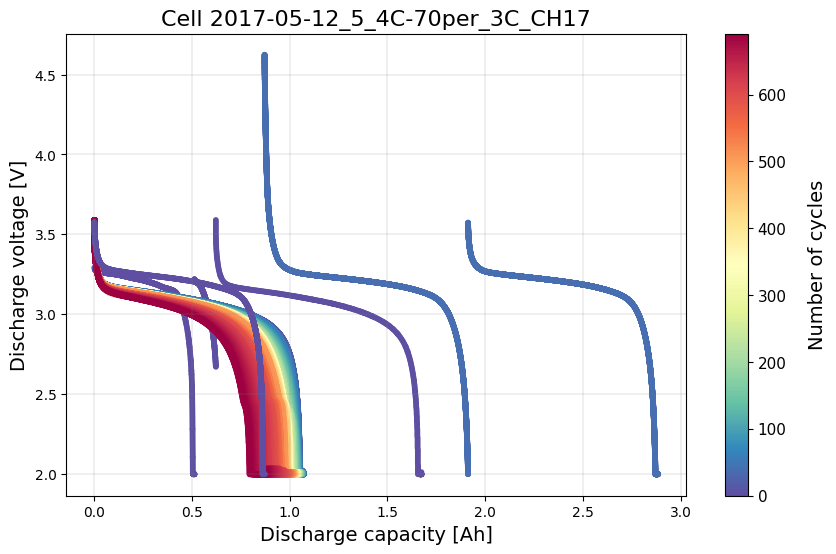

In [7]:
# If the true outlier cycle index is not known,
# cycling data will be plotted without labels
benchdb.plot_cycle_data(
    df_selected_cell_without_labels)

plt.show()

# Statistical Feature Transformation

To help with the separation of abnormal cycles from normal cycles, we propose a new statistical feature transformation method using the median and IQR of the input features:  

$$
\begin{equation}
x_\mathrm{scaled} = x_i - \left[\frac{\mathrm{median}(X)^{2}}{\mathrm{IQR}(X)}\right],
\end{equation} 
$$

where the IQR can be calculated from the third ($75^\mathrm{th}$ percentile) and first quartile ($25^\mathrm{th}$ percentile) of the input vector ($\mathrm{IQR}(X) = Q_3(X) - Q_1(X)$). Here, we use $\mathrm{median}(X)^2$ to preserve the physical unit of the original feature after feature transformation. Feature scaling is implemented on both the capacity and voltage data.

## Capacity scaling

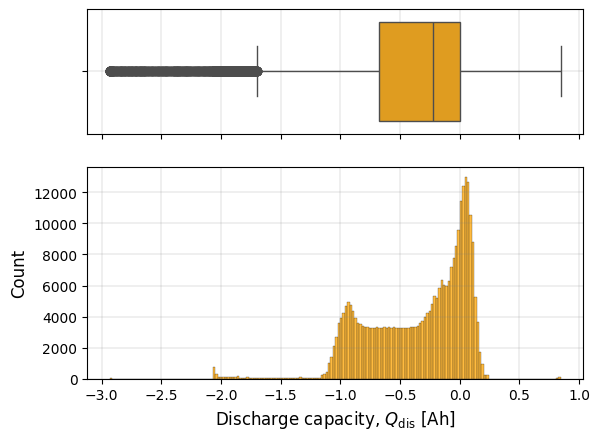

count    313326.000000
mean         -0.349626
std           0.414280
min          -2.933561
25%          -0.677412
50%          -0.226724
75%           0.005721
max           0.844670
Name: scaled_discharge_capacity, dtype: float64
**********************************************************************


0        -0.828787
1        -0.827432
2        -0.825870
3        -0.824306
4        -0.824306
            ...   
301553   -0.145985
301554   -0.145915
301555   -0.145915
301556   -0.145867
301557   -0.145867
Name: scaled_discharge_capacity, Length: 313326, dtype: float64

In [8]:
# Instantiate the CycleScaling class
scaler = CycleScaling(
    df_selected_cell=df_selected_cell_without_labels)

# Implement median IQR scaling on the discharge capacity data
df_capacity_med_scaled = scaler.median_IQR_scaling(
    variable="discharge_capacity",
    validate=True)

# Plot the histogram and boxplot of the scaled data
ax_hist = bviz.hist_boxplot(
    df_variable=df_capacity_med_scaled["scaled_discharge_capacity"])

ax_hist.set_xlabel(
    r"Discharge capacity, $Q_\mathrm{dis}$ [Ah]",
    fontsize=12)
ax_hist.set_ylabel(
    r"Count",
    fontsize=12)

plt.show()

# Print the summary statistics of the scaled capacity data
print(df_capacity_med_scaled["scaled_discharge_capacity"].describe())
print("*"*70)

df_capacity_med_scaled["scaled_discharge_capacity"]

## Voltage scaling

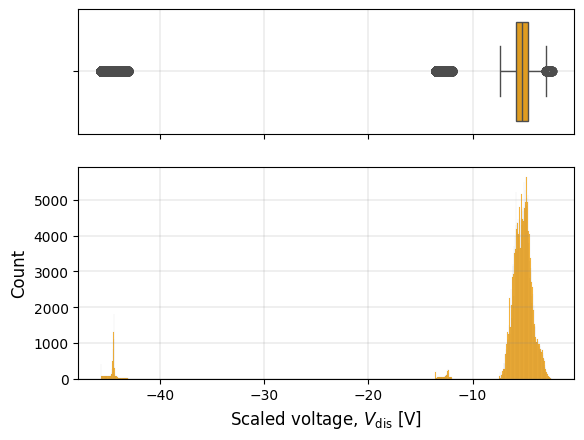

count    313326.000000
mean         -6.557421
std           7.159671
min         -45.644671
25%          -5.844655
50%          -5.215267
75%          -4.672330
max          -2.395836
Name: scaled_voltage, dtype: float64
**********************************************************************


0        -12.262836
1        -12.272870
2        -12.276842
3        -12.279593
4        -12.279593
            ...    
301553    -4.257652
301554    -4.257553
301555    -4.257553
301556    -4.257912
301557    -4.254364
Name: scaled_voltage, Length: 313326, dtype: float64

In [9]:
# Implement median IQR scaling on the discharge voltage data
df_voltage_med_scaled = scaler.median_IQR_scaling(
    variable="voltage",
    validate=True)

# Plot the histogram and boxplot of the scaled data
ax_hist = bviz.hist_boxplot(
    df_variable=df_voltage_med_scaled["scaled_voltage"])

ax_hist.set_xlabel(
    r"Scaled voltage, $V_\mathrm{dis}$ [V]",
    fontsize=12)
ax_hist.set_ylabel(
    r"Count",
    fontsize=12)

plt.show()

# Print the summary statistics of the scaled capacity data
print(df_voltage_med_scaled["scaled_voltage"].describe())
print("*"*70)
df_voltage_med_scaled["scaled_voltage"]

# Feature: dV

In [10]:
# maximum scaled voltage difference per cycle
df_max_dV = scaler.calculate_max_diff_per_cycle(
    df_scaled=df_voltage_med_scaled,
    variable_name="scaled_voltage")

df_max_dV

,max_diff,log_max_diff,cycle_index
0,1.564151,0.447343,0.0
1,0.023727,-3.741163,1.0
2,0.022684,-3.786091,2.0
3,0.027899,-3.579172,3.0
4,0.026408,-3.634081,4.0
...,...,...,...
687,0.046420,-3.070023,687.0
688,0.051542,-2.965352,688.0
689,0.047776,-3.041228,689.0
690,0.046331,-3.071935,690.0


In [11]:
max_dV_feature_stats = bstats.calculate_feature_stats(
    df_max_dV["max_diff"],
    new_col_name="max_diff_dV")

max_dV_feature_stats

Feature mean: 0.04105323627167629
Feature max: 2.612268400000005
Feature min: 0.022684100000000207
Feature std: 0.11397361246602544
**********************************************************************


,max_diff_dV
max,2.6123
min,0.0227
mean,0.0411
std,0.1140


## Standard deviation on dV

In [12]:
# Access the dict of parameters for using 
# the standard deviation method 
sd_param_dict = bstats.outlier_method["sd"].params
print(sd_param_dict)

# Predict the anomalous cycle using standard dev method 
# and the corresponding stats parameters
(SD_outlier_dV_index,
 SD_min_limit_dV,
 SD_max_limit_dV) = bstats.outlier_method["sd"].compute(
    df_max_dV["max_diff"], 
    **sd_param_dict)

{'std_dev_threshold': 3.0, 'ddof': 1}
SD feature mean: 0.04105323627167629
SD feature std: 0.11397361246602544
SD lower bound: -0.30086760112640004
SD upper bound: 0.3829740736697526
Std anomalous cycle index: [ 0 40]


## Feature mean and standard deviation without Z-transformation

In [13]:
# Mean and standard deviation of the feature dV
mean_dV = np.mean(df_max_dV["max_diff"])
std_dV = np.std(df_max_dV["max_diff"], ddof=1)

# Get the normal cycles after removing SD detected outliers
df_max_dV_normal_std = df_max_dV[
    ~ df_max_dV["cycle_index"].isin(SD_outlier_dV_index)]

# Get the abnormal cycles detected by SD
df_max_dV_abnormal_std = df_max_dV[
    df_max_dV["cycle_index"].isin(SD_outlier_dV_index)]
abnormal_max_dV_std = df_max_dV_abnormal_std["max_diff"].values
print("Abnormal max_dV values detected by 3-SDs:")
print(abnormal_max_dV_std)

Abnormal max_dV values detected by 3-SDs:
[1.5641508 2.6122684]


## Z-score on dV

In [14]:
# Access the dict of parameters for using 
# the Z-score method 
zscore_param_dict = bstats.outlier_method["zscore"].params
print(zscore_param_dict)

# Predict the anomalous cycle using z-score method 
# and the corresponding stats parameters
(zscore_outlier_dV_index,
 zscore_min_limit_dV,
 zscore_max_limit_dV) = bstats.outlier_method["zscore"].compute(
    df_max_dV["max_diff"], 
    **zscore_param_dict)

{'zscore_threshold': 3.0, 'ddof': 1}
Feature mean: 0.04105323627167629
Feature std: 0.11397361246602544
----------------------------------------------------------------------
After Z-transformation, feature mean should be close to 0 and feature std should be close to 1.
Zscore feature mean: -2.0535917218500004e-17
Zscore feature std: 1.0
Zscore anomalous cycle index: (array([ 0, 40]),)


## Feature mean and standard deviation after Z-transformation

In [15]:
# Calculate the corresponding z-score of the feature dV
zscore_max_dV = bstats.calculate_zscore(df_max_dV["max_diff"])

# Create a new df with z-transformed feature 
# and the corresponding cycle index
df_zscore_dV = pd.concat(
    [zscore_max_dV, df_max_dV["cycle_index"]],
    axis=1)

# Calculate the mean and standard deviation of the 
# Z-transformed feature
mean_zscore = np.mean(zscore_max_dV)
std_zscore = np.std(zscore_max_dV)

Feature mean: 0.04105323627167629
Feature std: 0.11397361246602544
After Z-transformation, feature mean should be close to 0 and feature std should be close to 1.
Zscore feature mean: -2.0535917218500004e-17
Zscore feature std: 1.0


In [16]:
# Get the normal cycles after removing detected Z-anomalies
df_max_dV_normal_zscore = df_zscore_dV[
    ~ df_zscore_dV["cycle_index"].isin(zscore_outlier_dV_index)]

# Get the abnormal cycles detected by the Z-score method 
df_max_dV_abnormal_zscore = df_zscore_dV[
    df_zscore_dV["cycle_index"].isin(zscore_outlier_dV_index)]
abnormal_max_dV_zscore = df_max_dV_abnormal_zscore["max_diff"].values
print("Abnormal max_dV values detected by Z-score:")
print(abnormal_max_dV_zscore)

Abnormal max_dV values detected by Z-score:
[13.36359821 22.55974087]


# Feature: dVdQ

In [17]:
df_max_dVdQ = scaler.calculate_max_feature_derivative_per_cycle(
    Xfeature=df_capacity_med_scaled["scaled_discharge_capacity"],
    Yfeature=df_voltage_med_scaled["scaled_voltage"],
    cycle_index=df_voltage_med_scaled["cycle_index"])

df_max_dVdQ

/home/mcp/Documents/02_learning/02_osbad/osbad/src/osbad/scaler.py:265: RuntimeWarning: divide by zero encountered in divide
  feature_diff = numerator_feature_diff/denominator_feature_diff
/home/mcp/Documents/02_learning/02_osbad/osbad/src/osbad/scaler.py:265: RuntimeWarning: invalid value encountered in divide
  feature_diff = numerator_feature_diff/denominator_feature_diff


,max_diff,log_max_diff,cycle_index
0,178932.163746,12.094762,0.0
1,10.879725,2.386901,1.0
2,9.355405,2.235954,2.0
3,7.779197,2.051453,3.0
4,9.119772,2.210445,4.0
...,...,...,...
687,8.897922,2.185818,687.0
688,7.007765,1.947019,688.0
689,7.087613,1.958349,689.0
690,7.316459,1.990126,690.0


In [18]:
max_dVdQ_feature_stats = bstats.calculate_feature_stats(
    df_max_dVdQ["max_diff"],
    new_col_name="max_diff_dVdQ")

max_dVdQ_feature_stats

Feature mean: 321.2474799595723
Feature max: 178932.16374587023
Feature min: 4.1214299224441175
Feature std: 6918.580867088768
**********************************************************************


,max_diff_dVdQ
max,178932.1637
min,4.1214
mean,321.2475
std,6918.5809


## Standard deviation on log(dVdQ)

In [19]:
sd_param_dict = bstats.outlier_method["sd"].params
print(sd_param_dict)

(SD_outlier_dVdQ_index,
 SD_min_limit_dVdQ,
 SD_max_limit_dVdQ) = bstats.outlier_method["sd"].compute(
    df_max_dVdQ["log_max_diff"], 
    **sd_param_dict)

{'std_dev_threshold': 3.0, 'ddof': 1}
SD feature mean: 2.559537423618379
SD feature std: 0.6559262319497828
SD lower bound: 0.5917587277690308
SD upper bound: 4.527316119467727
Std anomalous cycle index: [ 0 40]


## Z-score on log(dVdQ)

In [20]:
zscore_param_dict = bstats.outlier_method["zscore"].params
print(zscore_param_dict)

(zscore_outlier_dVdQ_index,
 zscore_min_limit_dVdQ,
 zscore_max_limit_dVdQ) = bstats.outlier_method["zscore"].compute(
    df_max_dVdQ["log_max_diff"], 
    **zscore_param_dict)

{'zscore_threshold': 3.0, 'ddof': 1}
Feature mean: 2.559537423618379
Feature std: 0.6559262319497828
----------------------------------------------------------------------
After Z-transformation, feature mean should be close to 0 and feature std should be close to 1.
Zscore feature mean: 4.517901788070001e-16
Zscore feature std: 1.0
Zscore anomalous cycle index: (array([ 0, 40]),)


# Compare standard deviation vs Z-score

In [22]:
# Mean and standard deviation of the feature dVdQ
mean_dVdQ = np.mean(df_max_dVdQ["max_diff"])
std_dVdQ = np.std(df_max_dVdQ["max_diff"], ddof=1)

# Get the normal cycles after removing SD detected outliers
df_max_dVdQ_normal_std = df_max_dVdQ[
    ~ df_max_dVdQ["cycle_index"].isin(SD_outlier_dVdQ_index)]

# Get the abnormal cycles detected by SD
df_max_dVdQ_abnormal_std = df_max_dVdQ[
    df_max_dVdQ["cycle_index"].isin(SD_outlier_dVdQ_index)]
abnormal_max_dVdQ_std = df_max_dVdQ_abnormal_std["max_diff"].values

print("Abnormal max_dVdQ values detected by 3-SDs:")
print(abnormal_max_dVdQ_std)

Abnormal max_dVdQ values detected by 3-SDs:
[178932.16374587  33622.15384614]


In [23]:
# Calculate the corresponding z-score of the feature dVdQ
zscore_max_dVdQ = bstats.calculate_zscore(df_max_dVdQ["max_diff"])

# Calculate the mean and standard deviation of the 
# Z-transformed feature
mean_zscore = np.mean(zscore_max_dVdQ)
std_zscore = np.std(zscore_max_dVdQ, ddof=1)

# Create a new df with z-transformed feature 
# and the corresponding cycle index
df_zscore_dVdQ = pd.concat(
    [zscore_max_dVdQ, df_max_dVdQ["cycle_index"]],
    axis=1)

Feature mean: 321.2474799595723
Feature std: 6918.580867088768
After Z-transformation, feature mean should be close to 0 and feature std should be close to 1.
Zscore feature mean: -1.2834948261562503e-17
Zscore feature std: 1.0


In [27]:
# Get the normal cycles after removing detected Z-anomalies
df_max_dVdQ_normal_zscore = df_zscore_dVdQ[
    ~ df_zscore_dVdQ["cycle_index"].isin(zscore_outlier_dVdQ_index)]

# Get the abnormal cycles detected by the Z-score method 
df_max_dVdQ_abnormal_zscore = df_zscore_dVdQ[
    df_zscore_dVdQ["cycle_index"].isin(zscore_outlier_dVdQ_index)]
abnormal_max_dVdQ_zscore = df_max_dVdQ_abnormal_zscore["max_diff"].values

print("Abnormal max_dVdQ values detected by Z-score:")
print(abnormal_max_dVdQ_zscore)

Abnormal max_dVdQ values detected by Z-score:
[25.81612034  4.81325679]


# Plot the comparison

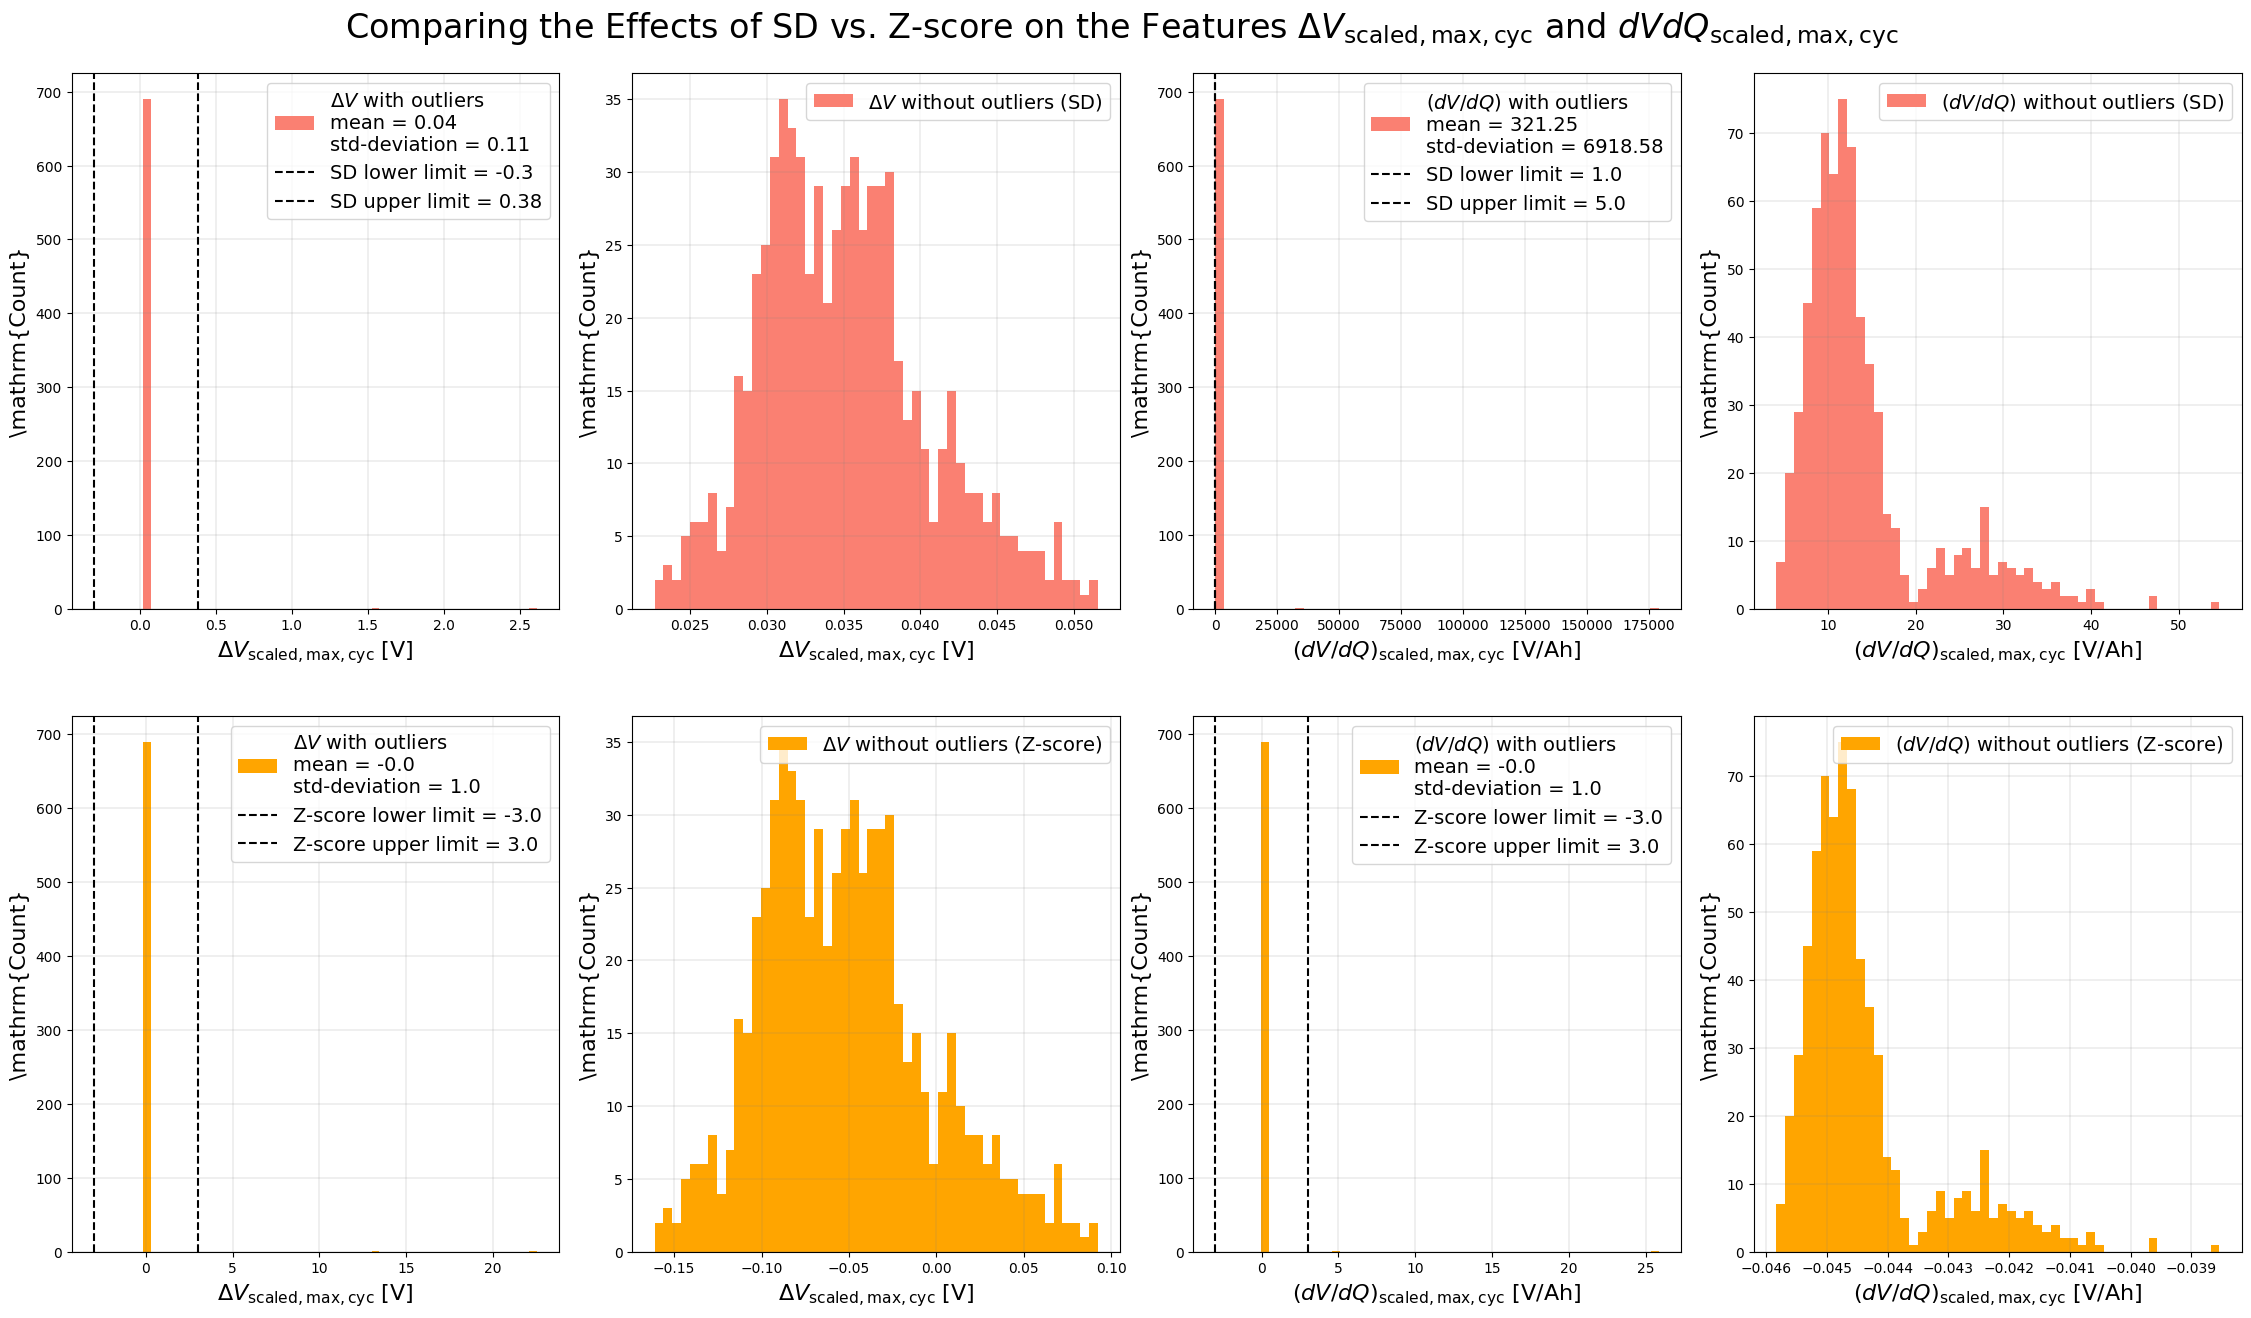

In [ ]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

fig = plt.figure(figsize=(28,32))
gs = fig.add_gridspec(4, 4, wspace=0.15)

# Standard deviation on dV with outliers ------------------------
ax1 = fig.add_subplot(gs[0])

# Plot histogram with the calculated mean 
# and std of the feature dV
ax1.hist(
    df_max_dV["max_diff"],
    bins=50,
    color="salmon",
    label=r"$\Delta V$ with outliers" 
        + "\n"
        + f"mean = {np.round(mean_dV, 2)}\n" 
        + f"std-deviation = {np.round(std_dV, 2)}")
ax1.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)

# SD min and max limits on dV
ax1.axvline(
    x=SD_min_limit_dV,
    color="black",
    linestyle="--",
    label=f"SD lower limit = {np.round(SD_min_limit_dV,2)}")
ax1.axvline(
    x=SD_max_limit_dV,
    color="black",
    linestyle="--",
    label=f"SD upper limit = {np.round(SD_max_limit_dV,2)}")


ax1.set_xlabel(
    r"$\Delta V_\mathrm{scaled,max,cyc}\;\mathrm{[V]}$",
    fontsize=16)
ax1.set_ylabel(
    r"\mathrm{Count}",
    fontsize=16)
ax1.legend(fontsize=14)

# Standard deviation on dV without outliers -----------

ax2 = fig.add_subplot(gs[1])

# Plot histogram without SD detected anomalies
ax2.hist(
    df_max_dV_normal_std["max_diff"],
    bins=50,
    color="salmon",
    label=r"$\Delta V$ without outliers (SD)")

ax2.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax2.legend(fontsize=14)
ax2.set_xlabel(
    r"$\Delta V_\mathrm{scaled,max,cyc}\;\mathrm{[V]}$",
    fontsize=16)
ax2.set_ylabel(
    r"\mathrm{Count}",
    fontsize=16)

# Standard deviation on dVdQ with outliers -----------

ax3 = fig.add_subplot(gs[2])
ax3.hist(
    df_max_dVdQ["max_diff"],
    bins=50,
    color="salmon",
    label=r"$(dV/dQ)$ with outliers" 
        + "\n"
        + f"mean = {np.round(mean_dVdQ, 2)}\n" 
        + f"std-deviation = {np.round(std_dVdQ, 2)}")

# SD min and max limits on dVdQ
ax3.axvline(
    x=SD_min_limit_dVdQ,
    color="black",
    linestyle="--",
    label=f"SD lower limit = {np.round(SD_min_limit_dVdQ)}")
ax3.axvline(
    x=SD_max_limit_dVdQ,
    color="black",
    linestyle="--",
    label=f"SD upper limit = {np.round(SD_max_limit_dVdQ)}")

ax3.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax3.legend(fontsize=14)
ax3.set_xlabel(
    r"$(dV/dQ)_\mathrm{scaled,max,cyc}$ [V/Ah]",
    fontsize=16)
ax3.set_ylabel(
    r"\mathrm{Count}",
    fontsize=16)

# Standard deviation on dVdQ without outliers -----------

ax4 = fig.add_subplot(gs[3])
ax4.hist(df_max_dVdQ_normal_std["max_diff"],
         bins=50,
         color="salmon",
         label=r"$(dV/dQ)$ without outliers (SD)")
ax4.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax4.legend(fontsize=14, loc="upper right")
ax4.set_xlabel(
    r"$(dV/dQ)_\mathrm{scaled,max,cyc}$ [V/Ah]",
    fontsize=16)
ax4.set_ylabel(
    r"\mathrm{Count}",
    fontsize=16)

# ----------------------------------------------------------------
# Z-score on dV 
ax5 = fig.add_subplot(gs[4])
ax5.hist(
    zscore_max_dV,
    bins=50,
    color="orange",
    label=r"$\Delta V$ with outliers"
        + "\n"
        + f"mean = {np.round(mean_zscore, 2)}\n"
        + f"std-deviation = {np.round(std_zscore, 2)}")
ax5.axvline(
    x=zscore_min_limit_dV,
    color="black",
    linestyle="--",
    label=f"Z-score lower limit = {np.round(zscore_min_limit_dV)}")

ax5.axvline(
    x=zscore_max_limit_dV,
    color="black",
    linestyle="--",
    label=f"Z-score upper limit = {np.round(zscore_max_limit_dV)}")

ax5.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax5.legend(fontsize=14)
# ax5.set_xlim([-10, 30])
ax5.set_xlabel(
    r"$\Delta V_\mathrm{scaled,max,cyc}\;\mathrm{[V]}$",
    fontsize=16)
ax5.set_ylabel(
    r"\mathrm{Count}",
    fontsize=16)

# --------------------------------------------------------
# Zscore on dV without outliers
ax6 = fig.add_subplot(gs[5])
ax6.hist(df_max_dV_normal_zscore["max_diff"],
         bins=50,
         color="orange",
         label=r"$\Delta V$ without outliers (Z-score)")
ax6.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax6.legend(fontsize=14)
ax6.set_xlabel(
    r"$\Delta V_\mathrm{scaled,max,cyc}\;\mathrm{[V]}$",
    fontsize=16)
ax6.set_ylabel(
    r"\mathrm{Count}",
    fontsize=16)

# --------------------------------------------------------------------
# Z-score on dVdQ 

ax7 = fig.add_subplot(gs[6])
ax7.hist(
    zscore_max_dVdQ,
    bins=50,
    color="orange",
    label=r"$(dV/dQ)$ with outliers" 
        + "\n"
        + f"mean = {np.round(mean_zscore, 2)}\n"
        + f"std-deviation = {np.round(std_zscore, 2)}")

ax7.axvline(
    x=zscore_min_limit_dVdQ,
    color="black",
    linestyle="--",
    label=f"Z-score lower limit = {np.round(zscore_min_limit_dVdQ)}")

ax7.axvline(
    x=zscore_max_limit_dVdQ,
    color="black",
    linestyle="--",
    label=f"Z-score upper limit = {np.round(zscore_max_limit_dVdQ)}")

ax7.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax7.legend(fontsize=14)
# ax7.set_xlim([-10, 30])
ax7.set_xlabel(
    r"$(dV/dQ)_\mathrm{scaled,max,cyc}$ [V/Ah]",
    fontsize=16)
ax7.set_ylabel(
    r"\mathrm{Count}",
    fontsize=16)

# ------------------------------------------------------------------
# Zscore on dVdQ without outliers

ax8 = fig.add_subplot(gs[7])
ax8.hist(df_max_dVdQ_normal_zscore["max_diff"],
         bins=50,
         color="orange",
         label=r"$(dV/dQ)$ without outliers (Z-score)")
ax8.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax8.legend(fontsize=14, loc="upper right")
ax8.set_xlabel(
    r"$(dV/dQ)_\mathrm{scaled,max,cyc}$ [V/Ah]",
    fontsize=16)
ax8.set_ylabel(
    r"\mathrm{Count}",
    fontsize=16)

# ---------------------------------------------------------------------
# Create common title for all subplots

fig_title=(
    r"Comparing the Effects of SD vs. Z-score on the Features $\Delta V_\mathrm{scaled,max,cyc}$ " 
    + r"and $dVdQ_\mathrm{scaled,max,cyc}$"
    + r"")

plt.suptitle(
    fig_title,
    y=0.90,
    fontsize=24)

plt.show()